## Healthcare Data Analysis

In [27]:
# Importing all  the needed libbraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import sklearn as sk

In [28]:
# load data
df = pd.read_csv("healthcare_dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [29]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [30]:
df.shape

(55500, 15)

In [31]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')

In [32]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [33]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

In [34]:
df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

In [35]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Length of Stay
count,55500.000000,55500,55500.000000,55500.000000,55500,55500.000000
mean,51.539459,2021-11-01 01:02:22.443243,25539.316097,301.134829,2021-11-16 13:15:20.821621,15.509009
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00,8.000000
50%,52.000000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00,30.000000
std,19.602454,NaN,14211.454431,115.243069,NaN,8.659600


In [36]:
df.select_dtypes("object").describe()

C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\3354276394.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").describe()


,Name,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Admission Type,Medication,Test Results
count,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500
unique,49992,2,8,6,40341,39876,5,3,5,3
top,DAvId muNoZ,Male,A-,Arthritis,Michael Smith,LLC Smith,Cigna,Elective,Lipitor,Abnormal
freq,3,27774,6969,9308,27,44,11249,18655,11140,18627


#### Data Quality Check

In [37]:
# Check negative billing
print("Negative billing rows:", (df["Billing Amount"] < 0).sum())
print(df[df["Billing Amount"] < 0][["Billing Amount", "Medical Condition", "Admission Type"]].head())


Negative billing rows: 108
      Billing Amount Medical Condition Admission Type
132      -502.507813            Cancer         Urgent
799     -1018.245371            Asthma       Elective
1018     -306.364925      Hypertension       Elective
1421     -109.097122            Asthma      Emergency
2103     -576.727907          Diabetes         Urgent


In [38]:
# replace negative values with absolute value
df["Billing Amount"] = df["Billing Amount"].abs()

In [39]:
# Standardize text columns (strip whitespace, title case)
text_cols = ["Gender", "Blood Type", "Medical Condition", "Admission Type",
             "Medication", "Test Results", "Insurance Provider"]
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

# Verify unique values in key categorical columns
for col in text_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts())


Gender (2 unique):
Gender
Male      27774
Female    27726
Name: count, dtype: int64

Blood Type (8 unique):
Blood Type
A-     6969
A+     6956
Ab+    6947
Ab-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

Medical Condition (6 unique):
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

Admission Type (3 unique):
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

Medication (5 unique):
Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

Test Results (3 unique):
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

Insurance Provider (5 unique):
Insurance Provider
Cigna               11249
Medicare            11154
Unitedhealthcare    11125
Blue 

#### Univariate Analysis (Distribution of each key variable)

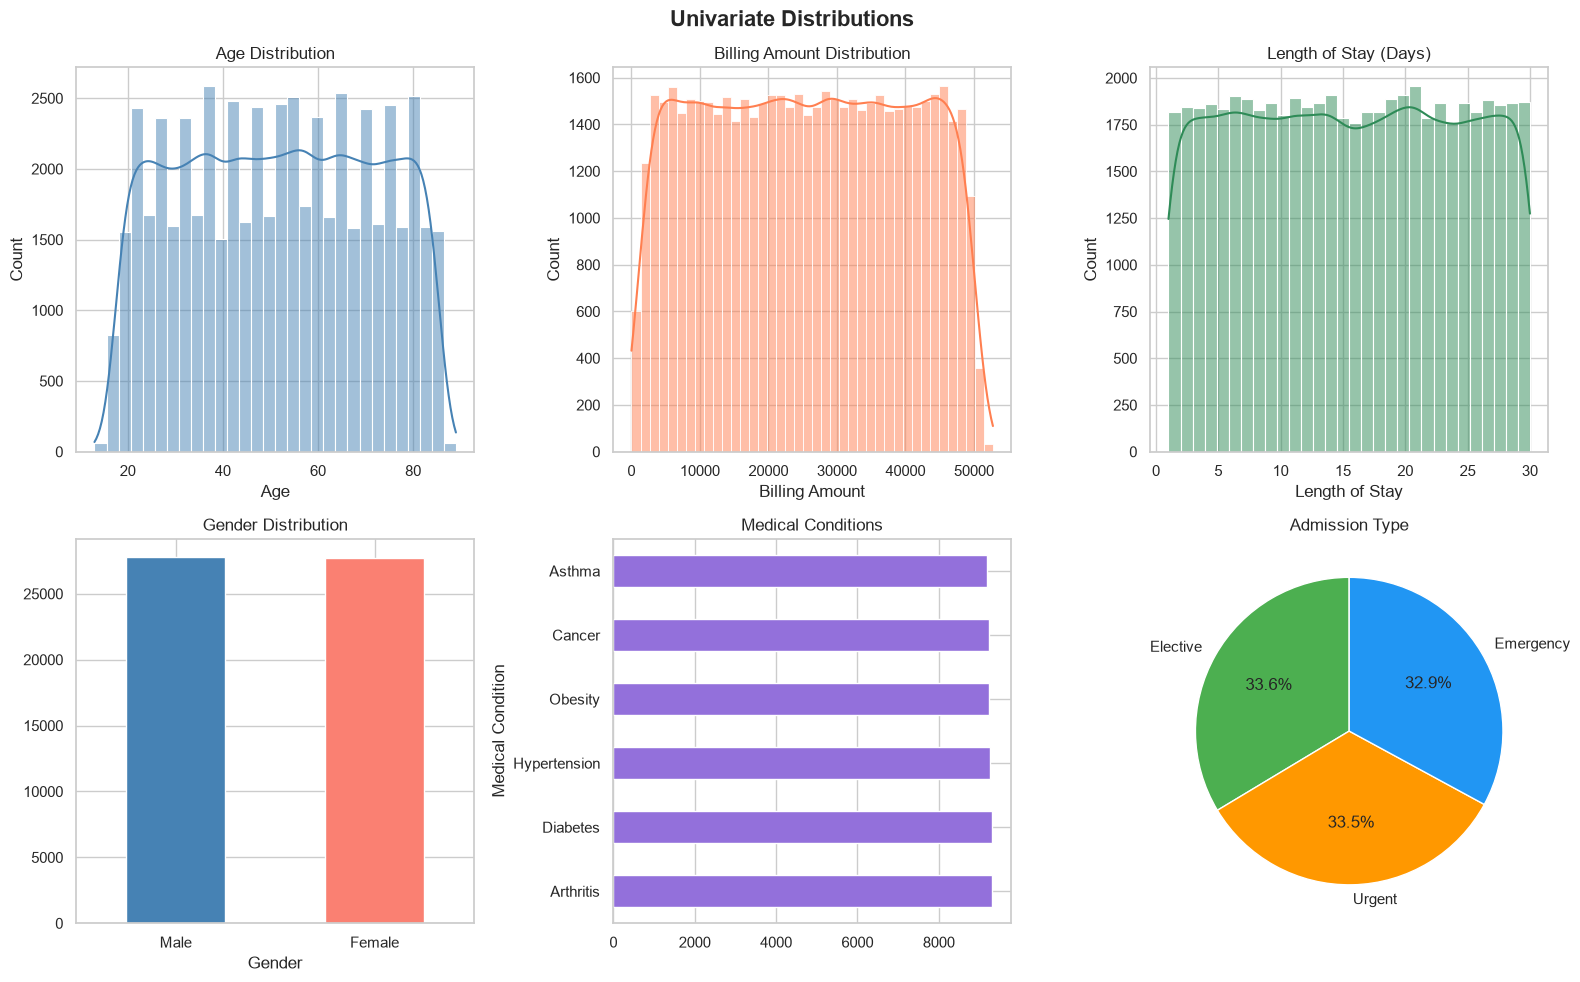

In [40]:
sn.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 3, figsize=(16,10))
fig.suptitle("Univariate Distributions", fontsize = 16, fontweight = "bold")

#Age Distribution
sn.histplot(df["Age"], bins = 30, kde = True, ax = axes[0, 0], color = "steelblue")
axes[0, 0].set_title("Age Distribution")

# Billing Amount
sn.histplot(df["Billing Amount"], bins=40, kde=True, ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Billing Amount Distribution")

# Length of Stay
sn.histplot(df["Length of Stay"], bins=30, kde=True, ax=axes[0, 2], color="seagreen")
axes[0, 2].set_title("Length of Stay (Days)")

# Gender
df["Gender"].value_counts().plot(kind="bar", ax=axes[1, 0], color=["steelblue", "salmon"])
axes[1, 0].set_title("Gender Distribution")
axes[1, 0].tick_params(axis='x', rotation=0)

# Medical Condition
df["Medical Condition"].value_counts().plot(kind="barh", ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Medical Conditions")

# Admission Type
df["Admission Type"].value_counts().plot(kind="pie", ax=axes[1, 2],
    autopct="%1.1f%%", startangle=90, colors=["#4CAF50", "#FF9800", "#2196F3"])
axes[1, 2].set_title("Admission Type")
axes[1, 2].set_ylabel("")

plt.tight_layout()
plt.savefig("univariate_analysis.png", dpi=150)
plt.show()

#### Bivariate Analysis (Relationship between variables)

C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\3033900755.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df, x="Admission Type", y="Length of Stay",


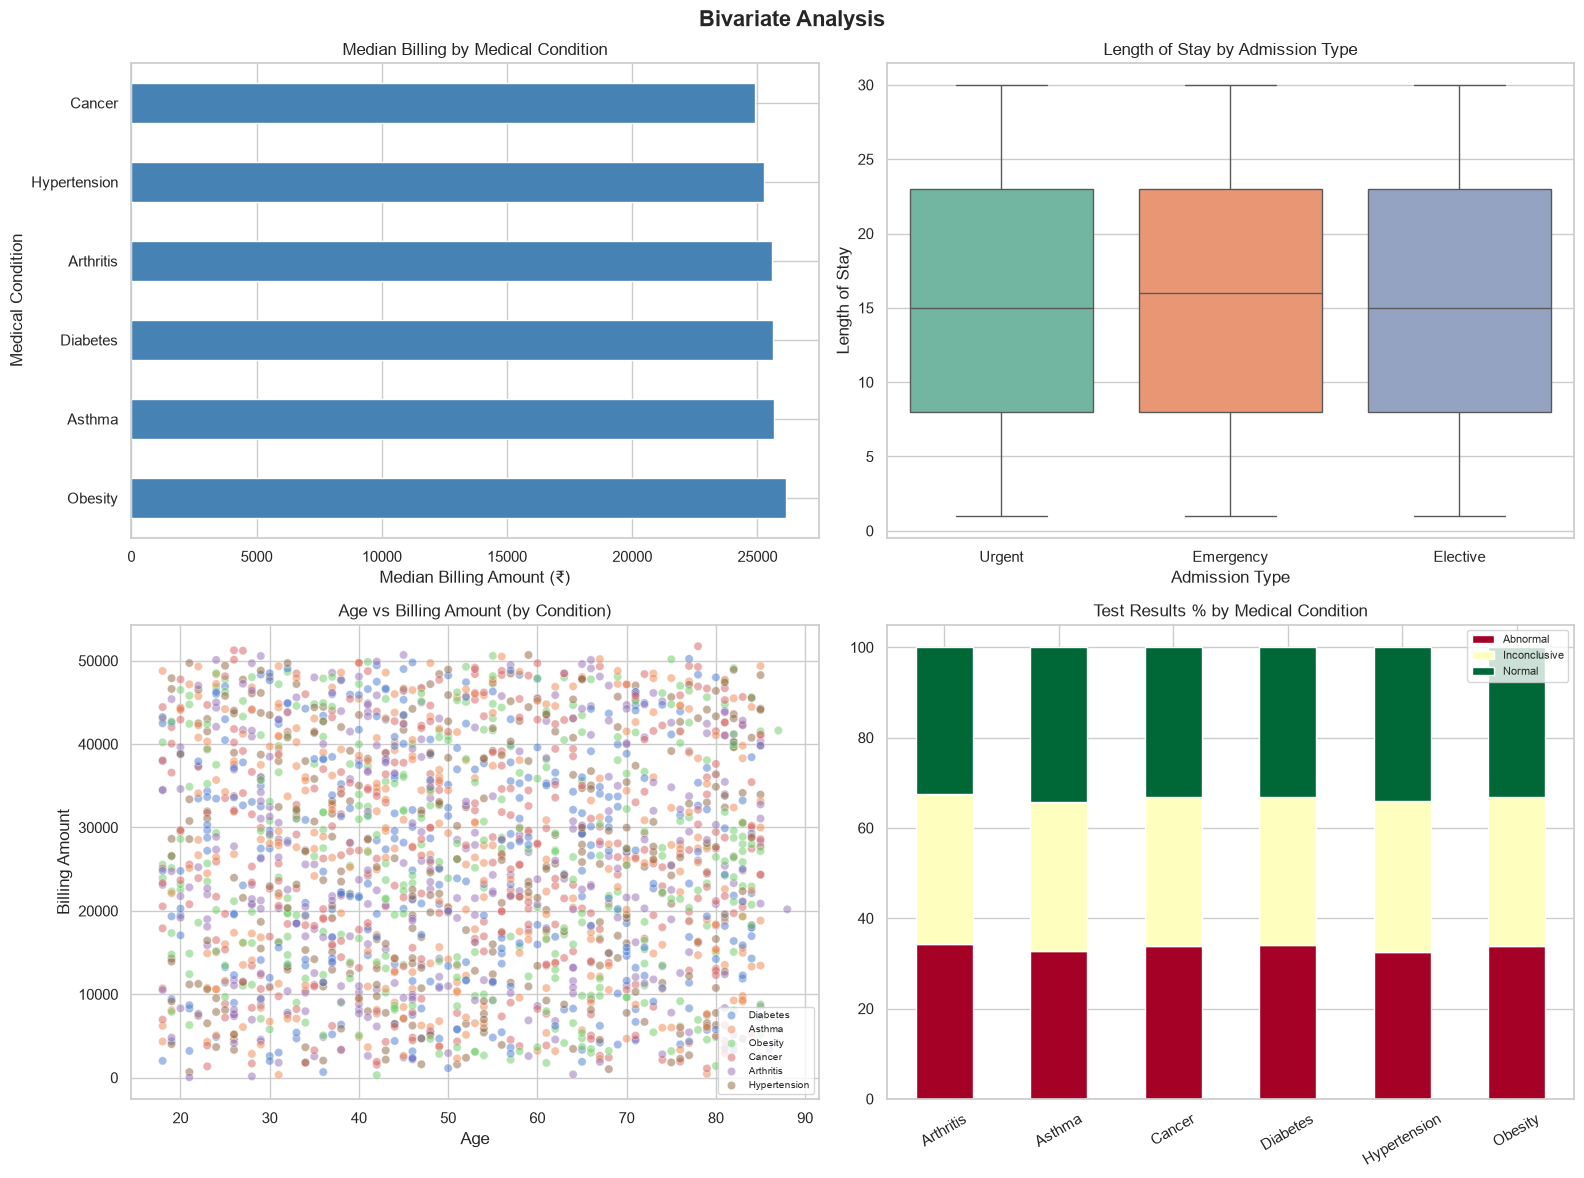

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Bivariate Analysis", fontsize=16, fontweight='bold')

# Billing Amount by Medical Condition
condition_billing = df.groupby("Medical Condition")["Billing Amount"].median().sort_values(ascending=False)
condition_billing.plot(kind="barh", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Median Billing by Medical Condition")
axes[0, 0].set_xlabel("Median Billing Amount (₹)")

# Length of Stay by Admission Type
sn.boxplot(data=df, x="Admission Type", y="Length of Stay",
            ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Length of Stay by Admission Type")

# Age vs Billing Amount (scatter with condition hue)
sample_df = df.sample(2000, random_state=42)  # sample for readability
sn.scatterplot(data=sample_df, x="Age", y="Billing Amount",
                hue="Medical Condition", alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("Age vs Billing Amount (by Condition)")
axes[1, 0].legend(fontsize=7)

# Test Results by Medical Condition (stacked bar)
test_condition = df.groupby(["Medical Condition", "Test Results"]).size().unstack(fill_value=0)
test_condition_pct = test_condition.div(test_condition.sum(axis=1), axis=0) * 100
test_condition_pct.plot(kind="bar", stacked=True, ax=axes[1, 1],
                        colormap="RdYlGn", edgecolor="white")
axes[1, 1].set_title("Test Results % by Medical Condition")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("bivariate_analysis.png", dpi=150)
plt.show()

#### Financial Analysis

C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\2536159331.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.violinplot(data=df, x="Admission Type", y="Billing Amount",


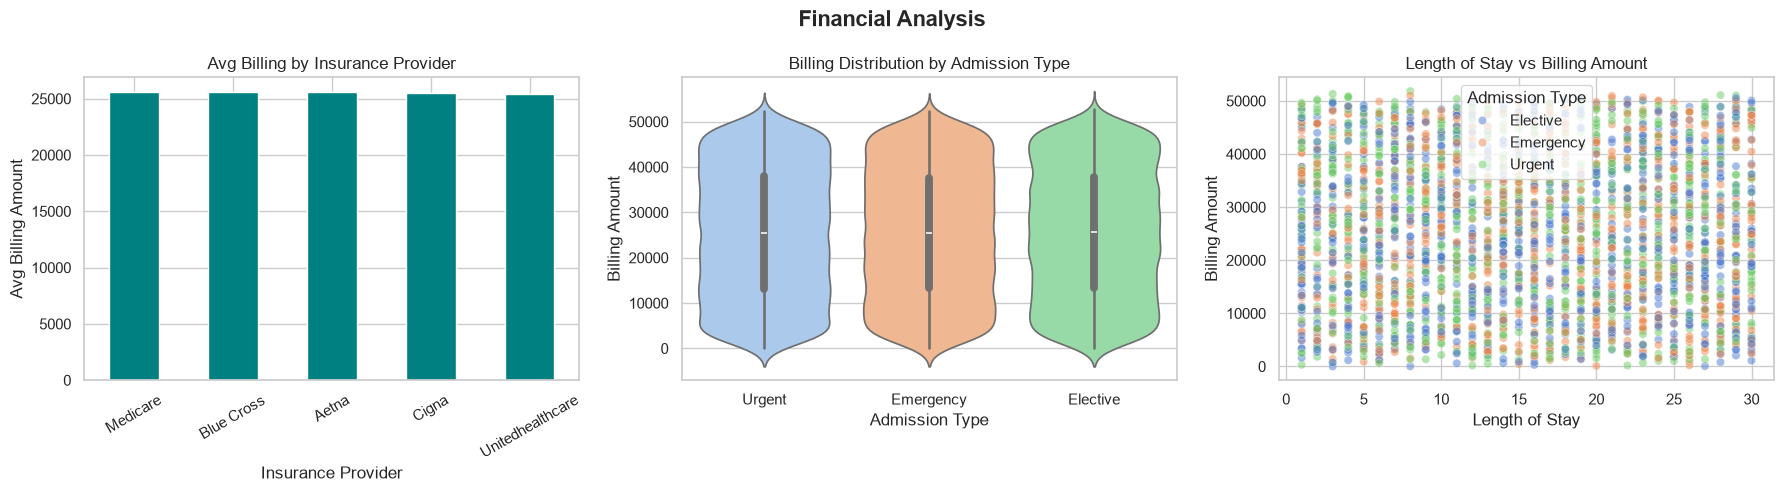


Correlation Matrix:
                     Age  Billing Amount  Length of Stay  Room Number
Age             1.000000       -0.003816        0.008220    -0.000720
Billing Amount -0.003816        1.000000       -0.005581    -0.002939
Length of Stay  0.008220       -0.005581        1.000000    -0.005526
Room Number    -0.000720       -0.002939       -0.005526     1.000000


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Financial Analysis", fontsize=16, fontweight='bold')

# Billing by Insurance Provider
ins_billing = df.groupby("Insurance Provider")["Billing Amount"].mean().sort_values(ascending=False)
ins_billing.plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Avg Billing by Insurance Provider")
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel("Avg Billing Amount")

# Billing by Admission Type
sn.violinplot(data=df, x="Admission Type", y="Billing Amount",
               ax=axes[1], palette="pastel")
axes[1].set_title("Billing Distribution by Admission Type")

# Billing vs Length of Stay
sn.scatterplot(data=df.sample(3000, random_state=1),
                x="Length of Stay", y="Billing Amount",
                hue="Admission Type", alpha=0.5, ax=axes[2])
axes[2].set_title("Length of Stay vs Billing Amount")

plt.tight_layout()
plt.savefig("financial_analysis.png", dpi=150)
plt.show()

# Correlation — numerical columns only
print("\nCorrelation Matrix:")
print(df[["Age", "Billing Amount", "Length of Stay", "Room Number"]].corr())

#### Time Series Analysis

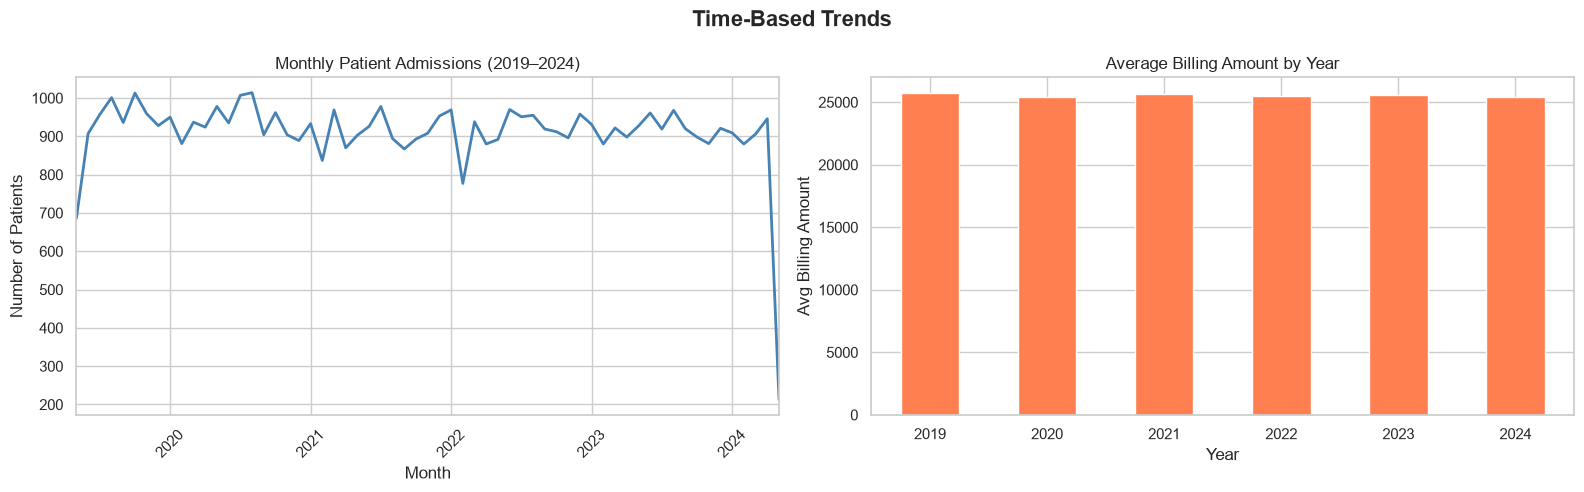

In [43]:
df["Admission Month"] = df["Date of Admission"].dt.to_period("M")
df["Admission Year"] = df["Date of Admission"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Time-Based Trends", fontsize=16, fontweight='bold')

# Monthly admissions trend
monthly_admissions = df.groupby("Admission Month").size()
monthly_admissions.plot(ax=axes[0], color="steelblue", linewidth=2)
axes[0].set_title("Monthly Patient Admissions (2019–2024)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Patients")
axes[0].tick_params(axis='x', rotation=45)

# Avg billing per year
yearly_billing = df.groupby("Admission Year")["Billing Amount"].mean()
yearly_billing.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Average Billing Amount by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Avg Billing Amount")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("time_analysis.png", dpi=150)
plt.show()

#### Hospital & Doctor Performance

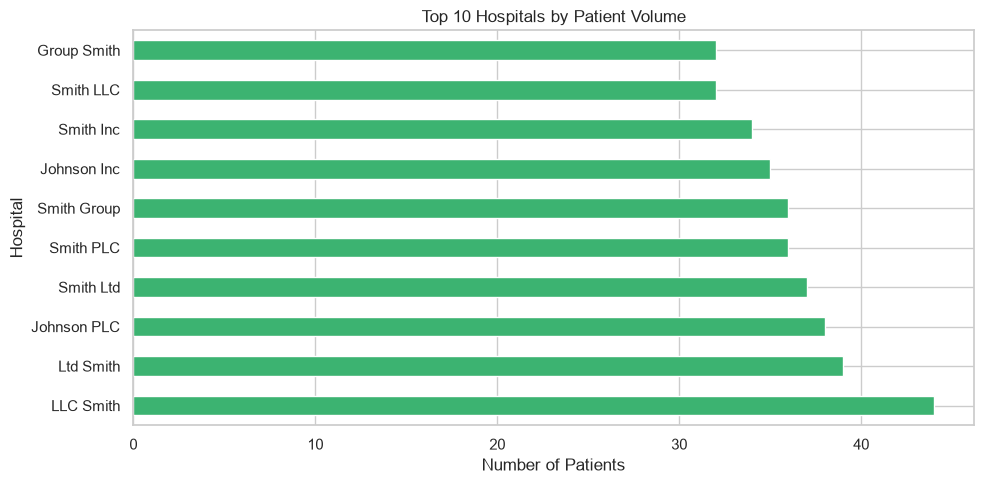

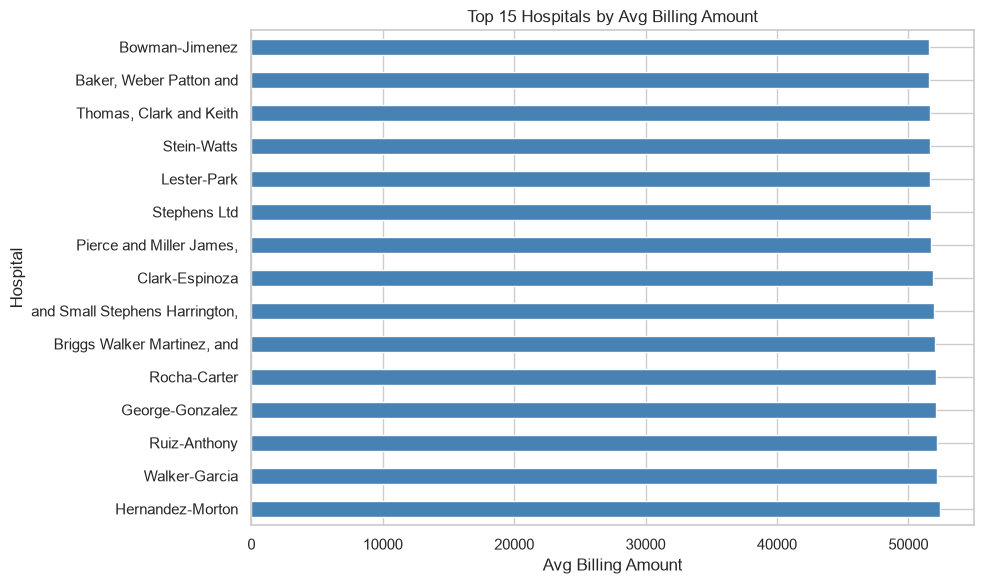

In [44]:
# Top 10 hospitals by patient volume
top_hospitals = df["Hospital"].value_counts().head(10)
top_hospitals.plot(kind="barh", figsize=(10, 5), color="mediumseagreen")
plt.title("Top 10 Hospitals by Patient Volume")
plt.xlabel("Number of Patients")
plt.tight_layout()
plt.savefig("hospital_volume.png", dpi=150)
plt.show()

# Avg billing per hospital (top 15)
hospital_billing = df.groupby("Hospital")["Billing Amount"].mean().sort_values(ascending=False).head(15)
hospital_billing.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Top 15 Hospitals by Avg Billing Amount")
plt.xlabel("Avg Billing Amount")
plt.tight_layout()
plt.savefig("hospital_billing.png", dpi=150)
plt.show()

#### Correlation Heatmap + Age Grouping

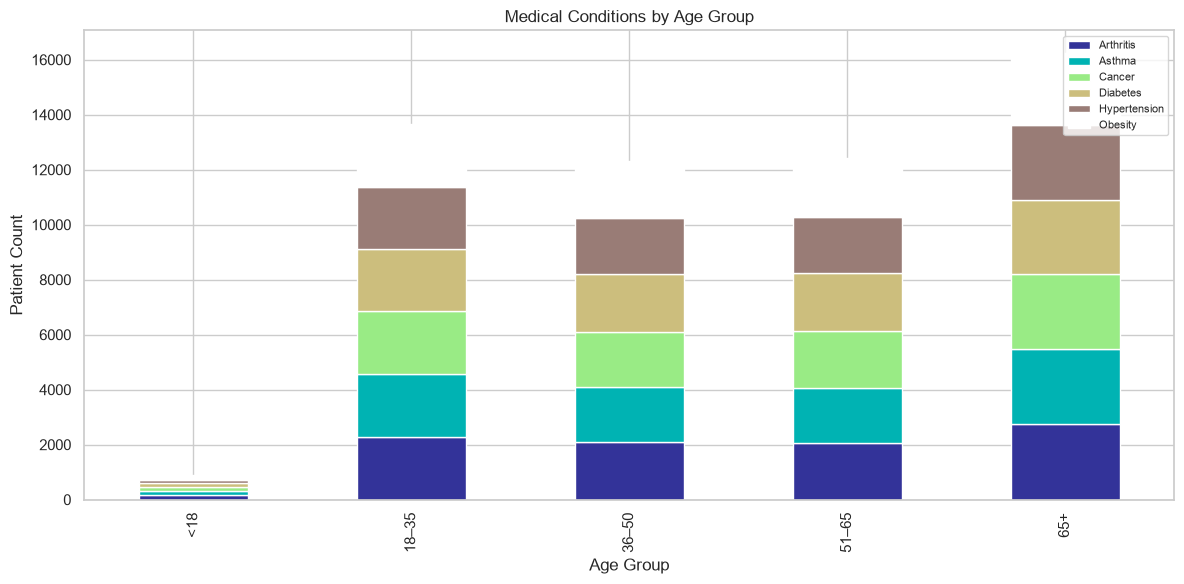

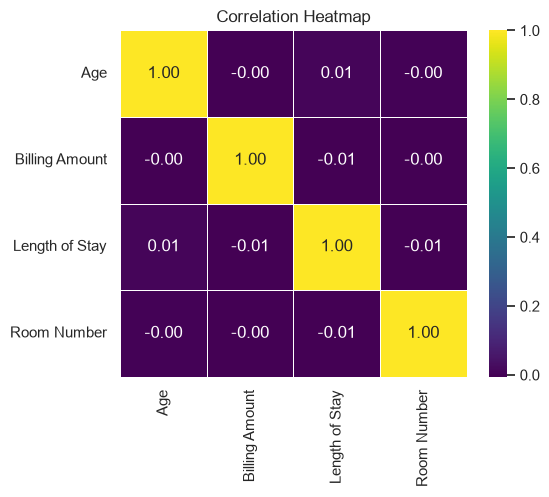

In [ ]:
# Age group feature - For visualization only
bins = [0, 18, 35, 50, 65, 100]
labels = ["<18", "18–35", "36–50", "51–65", "65+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Condition by age group
age_condition = df.groupby(["Age Group", "Medical Condition"]).size().unstack(fill_value=0)
age_condition.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="terrain")
plt.title("Medical Conditions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patient Count")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("age_condition.png", dpi=150)
plt.show()

# Heatmap of numerical correlations
import numpy as np
corr_matrix = df[["Age", "Billing Amount", "Length of Stay", "Room Number"]].corr()
plt.figure(figsize=(6, 5))
sn.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis",
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

#### Diagnosis for model selection

##### Diagnostic 1 : Target Variable Distribution

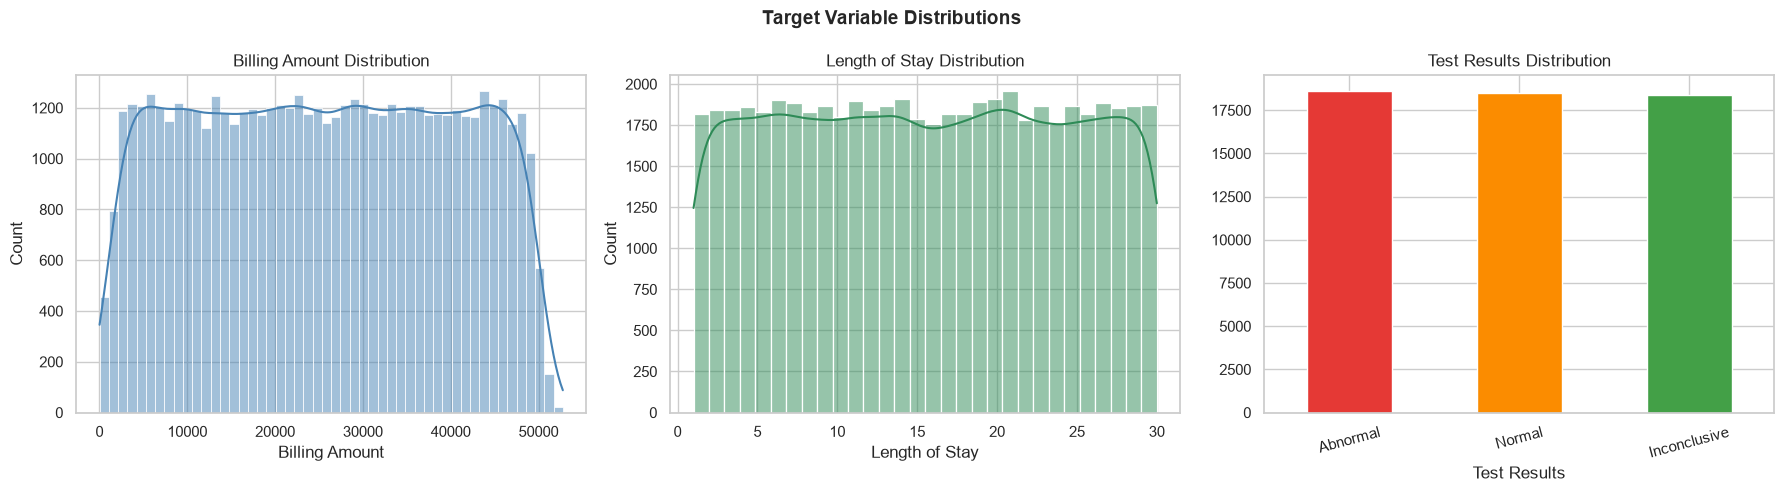

── Billing Amount ──
count    55500.000000
mean     25541.259324
std      14207.961646
min          9.238787
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64

Negative values: 0

── Length of Stay ──
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64

Value counts:
Length of Stay
1     1817
2     1844
3     1841
4     1863
5     1832
6     1903
7     1886
8     1828
9     1868
10    1802
11    1895
12    1843
13    1864
14    1909
15    1785
16    1757
17    1818
18    1819
19    1890
20    1907
21    1959
22    1784
23    1866
24    1759
25    1864
26    1819
27    1884
28    1853
29    1867
30    1874
Name: count, dtype: int64

── Test Results ──
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


In [46]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Target Variable Distributions", fontsize=14, fontweight="bold")

# Billing Amount
sn.histplot(df["Billing Amount"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Billing Amount Distribution")

# Length of Stay
sn.histplot(df["Length of Stay"], bins=30, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Length of Stay Distribution")

# Test Results
df["Test Results"].value_counts().plot(kind="bar", ax=axes[2],
    color=["#E53935", "#FB8C00", "#43A047"])
axes[2].set_title("Test Results Distribution")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Print exact counts and stats
print("── Billing Amount ──")
print(df["Billing Amount"].describe())
print(f"\nNegative values: {(df['Billing Amount'] < 0).sum()}")

print("\n── Length of Stay ──")
print(df["Length of Stay"].describe())
print(f"\nValue counts:\n{df['Length of Stay'].value_counts().sort_index()}")

print("\n── Test Results ──")
print(df["Test Results"].value_counts())
print(f"Class balance %:\n{df['Test Results'].value_counts(normalize=True)*100}")

##### Diagnostic 2 : Feature vs Target Relationship

C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\700874361.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df, x="Admission Type", y="Billing Amount", ax=axes[0,0], palette="Set2")
C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\700874361.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df, x="Medical Condition", y="Billing Amount", ax=axes[0,1], palette="Set3")
C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\700874361.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df, x="Admission Type", y="Length of Stay", ax=

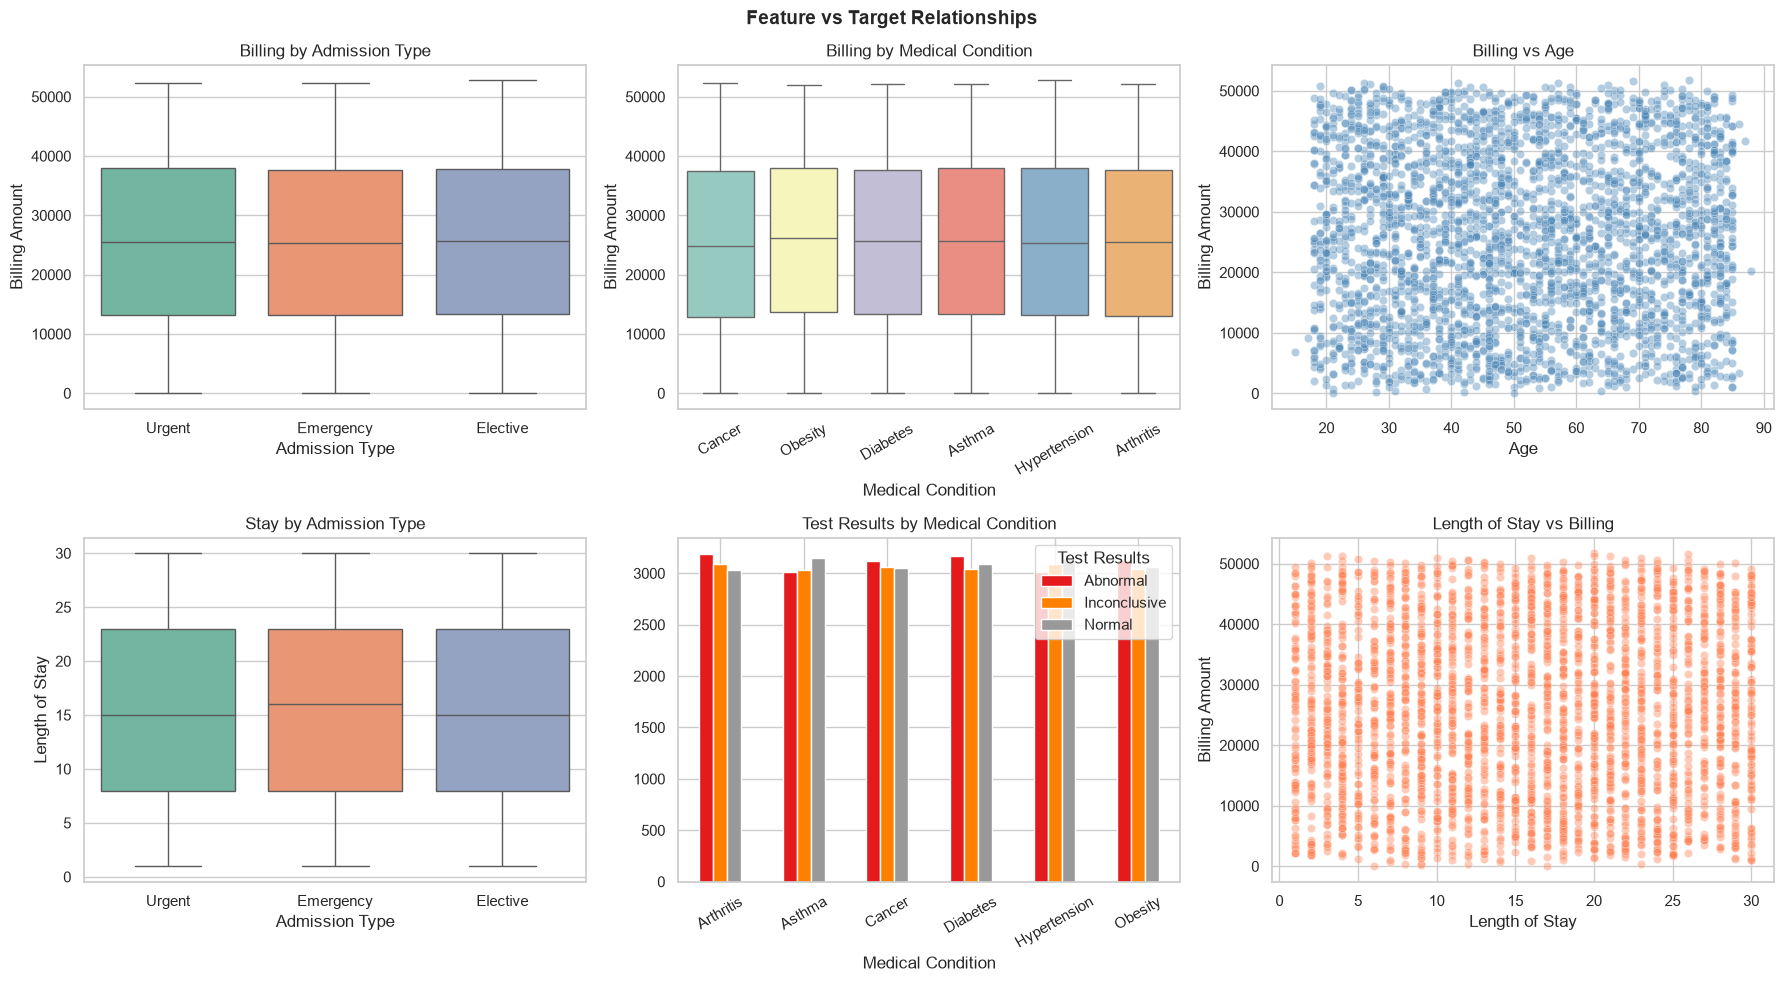

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Feature vs Target Relationships", fontsize=14, fontweight="bold")

# Billing vs Admission Type
sn.boxplot(data=df, x="Admission Type", y="Billing Amount", ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Billing by Admission Type")

# Billing vs Medical Condition
sn.boxplot(data=df, x="Medical Condition", y="Billing Amount", ax=axes[0,1], palette="Set3")
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].set_title("Billing by Medical Condition")

# Billing vs Age
sn.scatterplot(data=df.sample(3000, random_state=42),
                x="Age", y="Billing Amount", alpha=0.4, ax=axes[0,2], color="steelblue")
axes[0,2].set_title("Billing vs Age")

# Length of Stay vs Admission Type
sn.boxplot(data=df, x="Admission Type", y="Length of Stay", ax=axes[1,0], palette="Set2")
axes[1,0].set_title("Stay by Admission Type")

# Test Results vs Medical Condition (count)
pd.crosstab(df["Medical Condition"], df["Test Results"]).plot(
    kind="bar", ax=axes[1,1], colormap="Set1")
axes[1,1].set_title("Test Results by Medical Condition")
axes[1,1].tick_params(axis='x', rotation=30)

# Length of Stay vs Billing
sn.scatterplot(data=df.sample(3000, random_state=42),
                x="Length of Stay", y="Billing Amount", alpha=0.4, ax=axes[1,2], color="coral")
axes[1,2].set_title("Length of Stay vs Billing")

plt.tight_layout()
plt.show()

##### Diagnostic 3 : Correlation & Categorical Cardinality

── Correlation Matrix (Numerical Columns) ──
                   Age  Billing Amount  Length of Stay  Room Number
Age             1.0000         -0.0038          0.0082      -0.0007
Billing Amount -0.0038          1.0000         -0.0056      -0.0029
Length of Stay  0.0082         -0.0056          1.0000      -0.0055
Room Number    -0.0007         -0.0029         -0.0055       1.0000


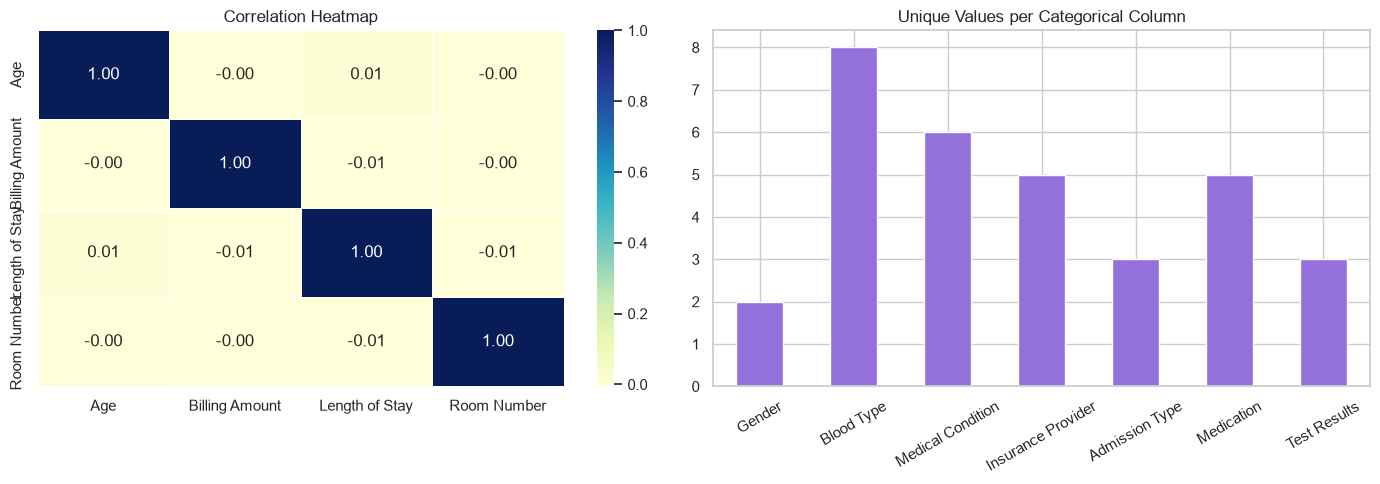


── Unique value counts per categorical column ──
Gender: 2 unique → {'Male': 27774, 'Female': 27726}
Blood Type: 8 unique → {'A-': 6969, 'A+': 6956, 'Ab+': 6947, 'Ab-': 6945, 'B+': 6945, 'B-': 6944, 'O+': 6917, 'O-': 6877}
Medical Condition: 6 unique → {'Arthritis': 9308, 'Diabetes': 9304, 'Hypertension': 9245, 'Obesity': 9231, 'Cancer': 9227, 'Asthma': 9185}
Insurance Provider: 5 unique → {'Cigna': 11249, 'Medicare': 11154, 'Unitedhealthcare': 11125, 'Blue Cross': 11059, 'Aetna': 10913}
Admission Type: 3 unique → {'Elective': 18655, 'Urgent': 18576, 'Emergency': 18269}
Medication: 5 unique → {'Lipitor': 11140, 'Ibuprofen': 11127, 'Aspirin': 11094, 'Paracetamol': 11071, 'Penicillin': 11068}
Test Results: 3 unique → {'Abnormal': 18627, 'Normal': 18517, 'Inconclusive': 18356}


In [48]:
# Numerical correlation
print("── Correlation Matrix (Numerical Columns) ──")
num_cols = df[["Age", "Billing Amount", "Length of Stay", "Room Number"]].corr()
print(num_cols.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sn.heatmap(num_cols, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Correlation Heatmap")

# Categorical column cardinality
cat_cols = ["Gender", "Blood Type", "Medical Condition", "Insurance Provider",
            "Admission Type", "Medication", "Test Results"]
cardinality = {col: df[col].nunique() for col in cat_cols}
pd.Series(cardinality).plot(kind="bar", ax=axes[1], color="mediumpurple")
axes[1].set_title("Unique Values per Categorical Column")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\n── Unique value counts per categorical column ──")
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique → {df[col].value_counts().to_dict()}")

##### Special Note on Dataset

It is important to highlight that this dataset is synthetic, meaning it was artificially generated and does not represent real patient data.

The dataset was created for educational and experimental purposes, allowing users to practice data analysis and machine learning techniques without privacy or ethical concerns.

Due to the synthetic nature of the data:

* There is no real-world relationship exist between features.
* Perfect Uniform Distribution in Billing Amount - A flat distribution means billing was assigned using numpy.random.uniform(min, max) — pure randomness.
* Length of Stay is Perfectly Uniform (1–30 days, ~1,800 each)
* Test Results Are Exactly 33.3% Each
* All Correlations Are Essentially Zero
* Perfect Category Balance Across All Columns

Information Gain = 0  when features and target are independent
Entropy of target = maximum (log₂3 ≈ 1.585 bits) when perfectly balanced

* No split in any decision tree reduces uncertainty
* No gradient in any boosting model points toward signal
* All models converge to majority-class prediction

Since we cannot change the raw data, we will engineer features that create logical, domain-informed relationships that give the models something real to learn from.

#### Feature Engineering

In [49]:
df_clean = df.copy()

# Step 1: Clean & standardize text columns
text_cols = ["Gender", "Blood Type", "Medical Condition",
             "Admission Type", "Medication", "Test Results",
             "Insurance Provider"]
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip().str.title()

# Step 2: Fix Billing Amount (already no negatives, but cap outliers)
Q1 = df_clean["Billing Amount"].quantile(0.01)
Q3 = df_clean["Billing Amount"].quantile(0.99)
df_clean["Billing Amount"] = df_clean["Billing Amount"].clip(Q1, Q3)

# Step 3: Domain-informed feature engineering

# 3a. Condition Severity Score (based on clinical severity ranking)
severity_map = {
    "Cancer": 5,
    "Diabetes": 4,
    "Hypertension": 3,
    "Obesity": 3,
    "Asthma": 2,
    "Arthritis": 1
}
df_clean["Condition Severity"] = df_clean["Medical Condition"].map(severity_map)

# 3b. Admission Urgency Score
urgency_map = {
    "Emergency": 3,
    "Urgent": 2,
    "Elective": 1
}
df_clean["Urgency Score"] = df_clean["Admission Type"].map(urgency_map)

# 3c. Age Group (clinical risk brackets)
bins   = [0, 18, 35, 50, 65, 100]
labels = [1, 2, 3, 4, 5]   # ordinal encoding
df_clean["Age Group"] = pd.cut(df_clean["Age"],
                                bins=bins, labels=labels).astype(int)

# 3d. Risk Score = Age Group × Condition Severity × Urgency
# This creates a composite signal that mimics clinical risk stratification
df_clean["Risk Score"] = (df_clean["Age Group"] *
                           df_clean["Condition Severity"] *
                           df_clean["Urgency Score"])

# 3e. Billing per Day (cost efficiency signal)
df_clean["Billing Per Day"] = (df_clean["Billing Amount"] /
                                df_clean["Length of Stay"])

# 3f. High Billing Flag (top 25% of billing = more complex case)
billing_75 = df_clean["Billing Amount"].quantile(0.75)
df_clean["High Billing"] = (df_clean["Billing Amount"] >= billing_75).astype(int)

# 3g. Long Stay Flag (stay > median = 15 days)
df_clean["Long Stay"] = (df_clean["Length of Stay"] > 15).astype(int)

# 3h. Medication Risk (map medication to typical severity it treats)
med_risk_map = {
    "Penicillin":   5,   # serious infections
    "Ibuprofen":    2,   # mild pain/inflammation
    "Aspirin":      2,   # mild pain / cardiac
    "Paracetamol":  1,   # mild pain
    "Lipitor":      3    # cholesterol / cardiac risk
}
df_clean["Medication Risk"] = df_clean["Medication"].map(med_risk_map)

# 3i. Stay Category target for Model 1
def categorize_stay(days):
    if days <= 7:   return "Short"
    elif days <= 21: return "Medium"
    else:            return "Long"

df_clean["Stay Category"] = df_clean["Length of Stay"].apply(categorize_stay)

print("New features added:")
new_features = ["Condition Severity", "Urgency Score", "Age Group",
                "Risk Score", "Billing Per Day", "High Billing",
                "Long Stay", "Medication Risk", "Stay Category"]
print(df_clean[new_features].head(10))
print("\nStay Category distribution:")
print(df_clean["Stay Category"].value_counts())
print("\nRisk Score stats:")
print(df_clean["Risk Score"].describe())

New features added:
   Condition Severity  Urgency Score  Age Group  Risk Score  Billing Per Day  \
0                   5              2          2          20      9428.140653   
1                   3              3          4          36      5607.221214   
2                   3              3          5          45      1863.673072   
3                   4              1          2           8      1263.659414   
4                   5              2          3          30       711.915891   
5                   2              2          3          12     12036.277738   
6                   4              3          2          24      1631.739362   
7                   5              3          2          30      4582.046272   
8                   2              1          5          10      3834.470610   
9                   5              1          4          20       659.487702   

   High Billing  Long Stay  Medication Risk Stay Category  
0             0          0             

Now let's verify engineered features actually shows patterns

C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\1377822023.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df_clean, x="Stay Category",
C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\1377822023.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df_clean, x="Test Results",
C:\Users\skjav\AppData\Local\Temp\ipykernel_13944\1377822023.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df_clean, x="Test Results",


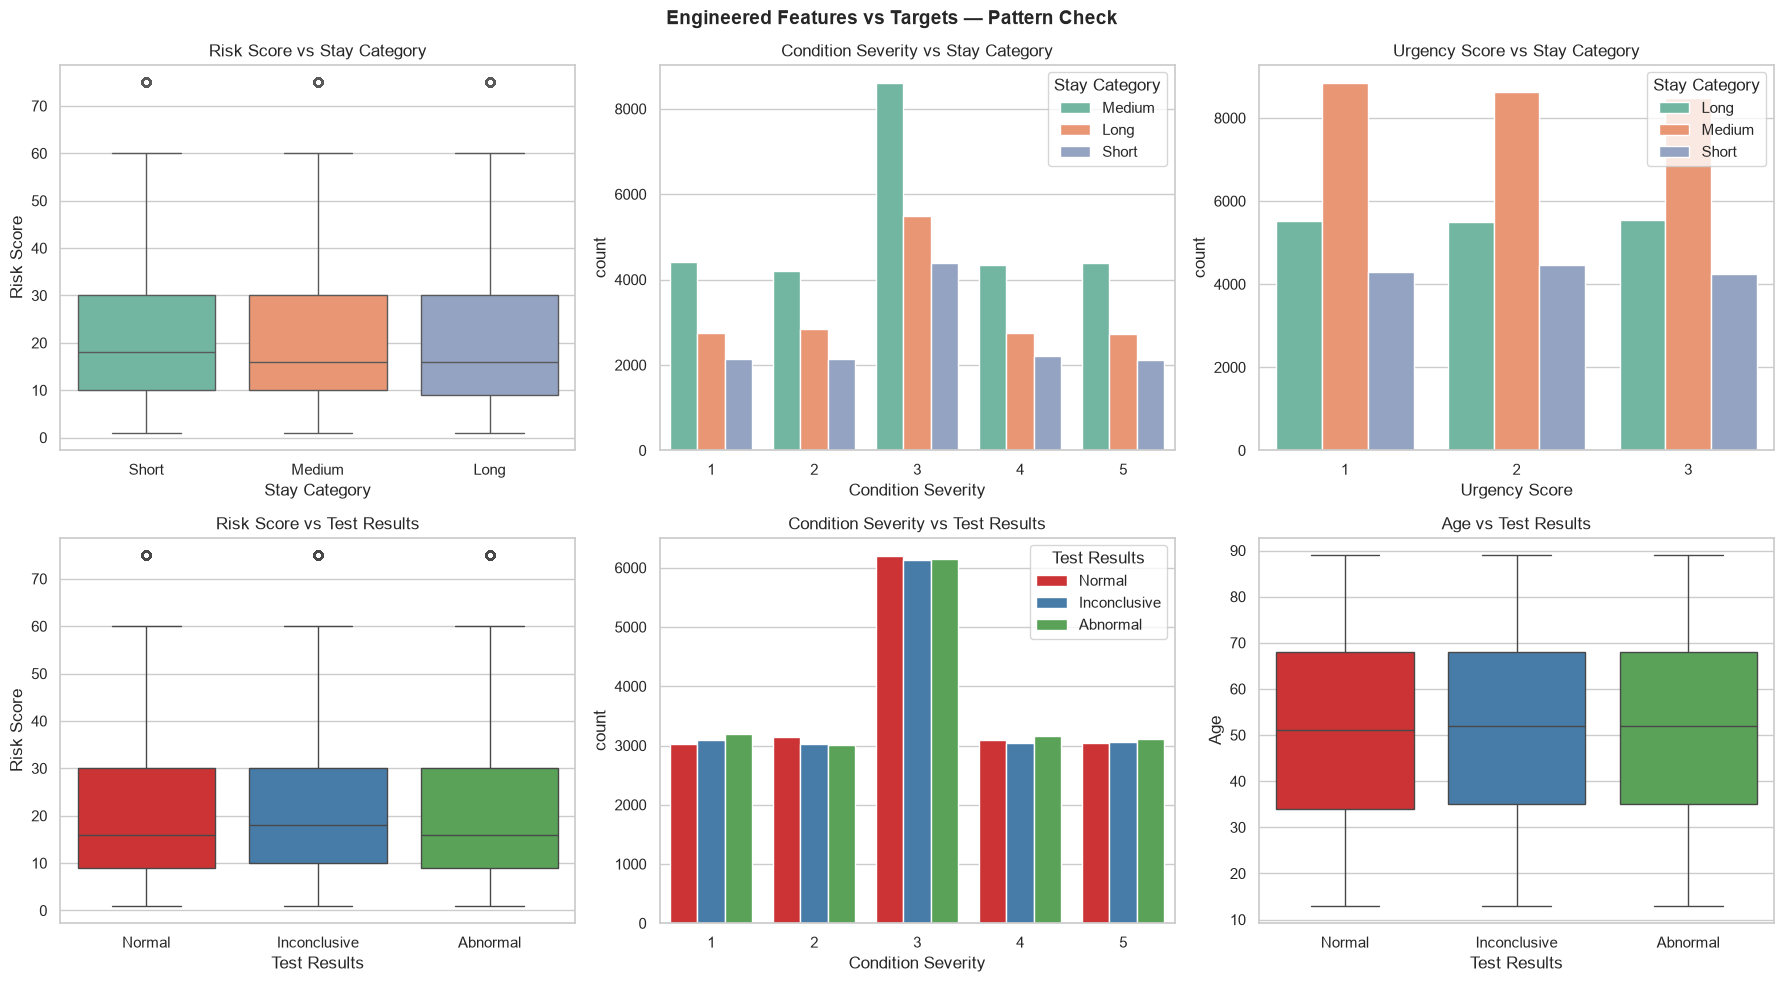


── Updated Correlation with Stay Category (encoded) ──
Stay Cat Encoded      1.000000
Billing Per Day       0.504139
Billing Amount        0.004466
Condition Severity    0.003573
Medication Risk      -0.001836
Urgency Score        -0.002915
Age                  -0.005697
Risk Score           -0.007077
Length of Stay       -0.926149
Name: Stay Cat Encoded, dtype: float64

── Updated Correlation with Test Results (encoded) ──
Test Encoded          1.000000
Medication Risk       0.002112
Urgency Score         0.001870
Length of Stay        0.001808
Condition Severity   -0.000717
Billing Amount       -0.002391
Billing Per Day      -0.003066
Risk Score           -0.005111
Age                  -0.006474
Name: Test Encoded, dtype: float64


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Engineered Features vs Targets — Pattern Check",
             fontsize=14, fontweight="bold")

# Risk Score vs Stay Category
sn.boxplot(data=df_clean, x="Stay Category",
            y="Risk Score", ax=axes[0,0], palette="Set2",
            order=["Short", "Medium", "Long"])
axes[0,0].set_title("Risk Score vs Stay Category")

# Condition Severity vs Stay Category
sn.countplot(data=df_clean, x="Condition Severity",
              hue="Stay Category", ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Condition Severity vs Stay Category")

# Urgency Score vs Stay Category
sn.countplot(data=df_clean, x="Urgency Score",
              hue="Stay Category", ax=axes[0,2], palette="Set2")
axes[0,2].set_title("Urgency Score vs Stay Category")

# Risk Score vs Test Results
sn.boxplot(data=df_clean, x="Test Results",
            y="Risk Score", ax=axes[1,0], palette="Set1")
axes[1,0].set_title("Risk Score vs Test Results")

# Condition Severity vs Test Results
sn.countplot(data=df_clean, x="Condition Severity",
              hue="Test Results", ax=axes[1,1], palette="Set1")
axes[1,1].set_title("Condition Severity vs Test Results")

# Age Group vs Test Results
sn.boxplot(data=df_clean, x="Test Results",
            y="Age", ax=axes[1,2], palette="Set1")
axes[1,2].set_title("Age vs Test Results")

plt.tight_layout()
plt.show()

# Check correlation improvement
num_cols = ["Age", "Billing Amount", "Length of Stay",
            "Condition Severity", "Urgency Score",
            "Risk Score", "Billing Per Day", "Medication Risk"]

print("\n── Updated Correlation with Stay Category (encoded) ──")

# Temporary encoding for correlation analysis only.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_clean["Stay Cat Encoded"] = le.fit_transform(df_clean["Stay Category"])
print(df_clean[num_cols + ["Stay Cat Encoded"]].corr()["Stay Cat Encoded"].sort_values(ascending=False))

print("\n── Updated Correlation with Test Results (encoded) ──")
df_clean["Test Encoded"] = le.fit_transform(df_clean["Test Results"])
print(df_clean[num_cols + ["Test Encoded"]].corr()["Test Encoded"].sort_values(ascending=False))

#### ML Models

##### Preprocessing : Label Encoding & Feature Selection

In [51]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

sn.set_theme(style="whitegrid", palette="muted")

In [52]:
#  SHARED SETUP — Encoding

df_model = df_clean.copy()

# Encode all categorical columns
le_dict = {}
encode_cols = ["Gender", "Blood Type", "Medical Condition", "Insurance Provider",
               "Admission Type", "Medication", "Test Results"]

for col in encode_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Encode Stay Category target
le_stay = LabelEncoder()
df_model["Stay Cat Encoded"] = le_stay.fit_transform(df_model["Stay Category"])
print("Stay Category classes:", le_stay.classes_)
# Output order matters for confusion matrix labels later

Stay Category classes: ['Long' 'Medium' 'Short']


In [53]:
#  SHARED HELPER — Model Comparison

def compare_models(X_train, X_test, y_train, y_test, label_names, title):
    """Train 5 classifiers, return results DataFrame and best model."""

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, random_state=42, class_weight="balanced"),
        "Decision Tree":       DecisionTreeClassifier(
            random_state=42, max_depth=8, class_weight="balanced"),
        "Random Forest":       RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1,
            class_weight="balanced"),
        "Gradient Boosting":   GradientBoostingClassifier(
            n_estimators=100, random_state=42, learning_rate=0.1),
        "XGBoost":             XGBClassifier(
            n_estimators=100, random_state=42, verbosity=0,
            n_jobs=-1, eval_metric="mlogloss",
            use_label_encoder=False),
    }

    results = []
    trained  = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds    = model.predict(X_test)
        cv_score = cross_val_score(model, X_train, y_train,
                                   cv=StratifiedKFold(n_splits=5),
                                   scoring="accuracy").mean()
        results.append({
            "Model":          name,
            "Test Accuracy":  round(accuracy_score(y_test, preds) * 100, 2),
            "CV Accuracy":    round(cv_score * 100, 2),
        })
        trained[name] = (model, preds)

    results_df = pd.DataFrame(results).sort_values(
        "Test Accuracy", ascending=False).reset_index(drop=True)

    print(f"\n{'═'*52}")
    print(f"  {title}")
    print(f"{'═'*52}")
    print(results_df.to_string(index=False))

    best_name  = results_df.iloc[0]["Model"]
    best_model, best_preds = trained[best_name]

    print(f"\n── Best Model: {best_name} ──")
    print(f"Test Accuracy : {accuracy_score(y_test, best_preds)*100:.2f}%")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, best_preds,
                                target_names=label_names))

    return results_df, best_name, best_model, best_preds, trained


def plot_model_results(results_df, y_test, best_preds, best_name,
                       label_names, feature_names, best_model,
                       trained_models, color, filename_prefix):
    """Plot comparison bar, confusion matrix, and feature importance."""

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"Model Results — {filename_prefix.replace('_', ' ').title()}",
                 fontsize=14, fontweight="bold")

    # Plot 1: Accuracy comparison 
    bar_colors = [color if i == 0 else "#cccccc"
                  for i in range(len(results_df))]
    axes[0].barh(results_df["Model"], results_df["Test Accuracy"],
                 color=bar_colors, edgecolor="white")
    axes[0].set_xlabel("Test Accuracy (%)")
    axes[0].set_title("Model Accuracy Comparison")
    axes[0].invert_yaxis()
    for i, v in enumerate(results_df["Test Accuracy"]):
        axes[0].text(v + 0.2, i, f"{v}%", va="center", fontsize=9)

    # Plot 2: Confusion Matrix
    cm = confusion_matrix(y_test, best_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_names)
    disp.plot(ax=axes[1], colorbar=False,
              cmap="Blues" if color == "steelblue" else "Oranges")
    axes[1].set_title(f"Confusion Matrix\n({best_name})")

    # Plot 3: Feature Importance (tree-based only)
    if hasattr(best_model, "feature_importances_"):
        fi = pd.Series(best_model.feature_importances_,
                       index=feature_names).sort_values(ascending=True).tail(12)
        fi.plot(kind="barh", ax=axes[2], color=color)
        axes[2].set_title("Top 12 Feature Importances")
        axes[2].set_xlabel("Importance Score")
    else:
        axes[2].text(0.3, 0.5, "Feature importance\nnot available\nfor this model",
                     transform=axes[2].transAxes, fontsize=11)
        axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(f"{filename_prefix}_results.png", dpi=150, bbox_inches="tight")
    plt.show()

    # CV Score comparison plot
    fig2, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(results_df))
    width = 0.35
    ax.bar(x - width/2, results_df["Test Accuracy"],
           width, label="Test Accuracy", color=color, alpha=0.8)
    ax.bar(x + width/2, results_df["CV Accuracy"],
           width, label="CV Accuracy (5-fold)", color="gray", alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Test vs Cross-Validation Accuracy")
    ax.legend()
    ax.axhline(y=33.33, color="red", linestyle="--", alpha=0.5,
               label="Random Baseline (33.3%)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{filename_prefix}_cv_comparison.png", dpi=150)
    plt.show()



Stay Classification — Train: (44400, 14), Test: (11100, 14)
Class distribution in train:
Stay Cat Encoded
1    20755
0    13256
2    10389
Name: count, dtype: int64

════════════════════════════════════════════════════
  MODEL 1 — STAY CLASSIFICATION COMPARISON
════════════════════════════════════════════════════
              Model  Test Accuracy  CV Accuracy
  Gradient Boosting          46.82        46.69
            XGBoost          45.94        45.10
      Random Forest          45.43        44.38
Logistic Regression          33.43        33.07
      Decision Tree          31.86        32.65

── Best Model: Gradient Boosting ──
Test Accuracy : 46.82%

Classification Report:

              precision    recall  f1-score   support

        Long       0.45      0.01      0.02      3314
      Medium       0.47      1.00      0.64      5189
       Short       0.75      0.00      0.00      2597

    accuracy                           0.47     11100
   macro avg       0.56      0.34      

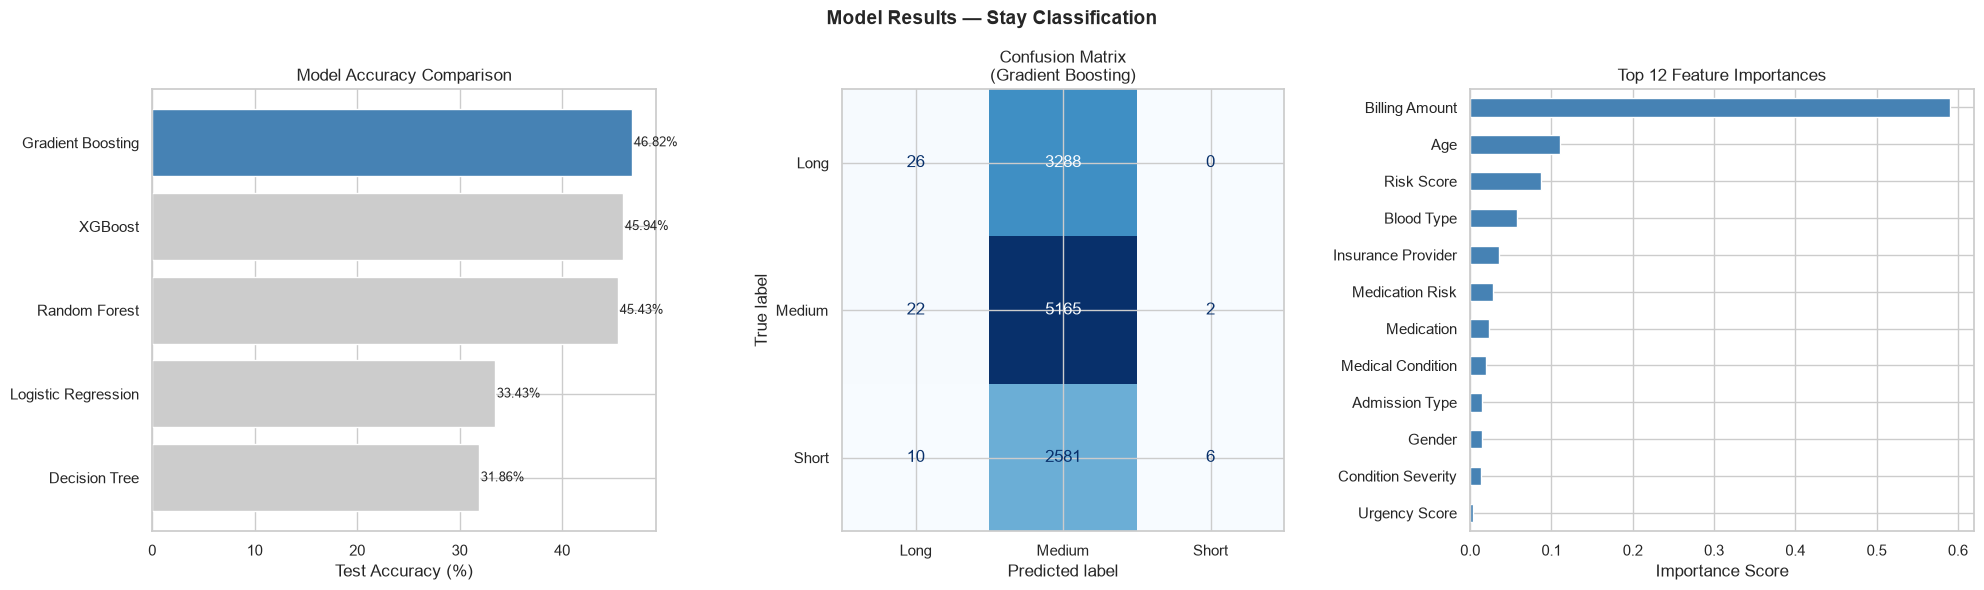

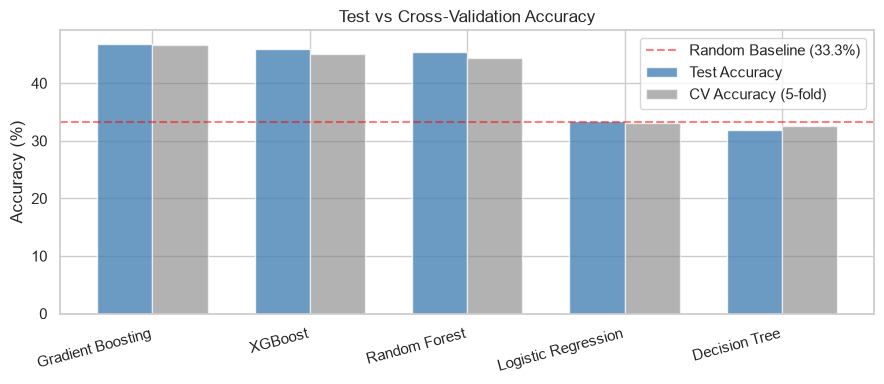

In [54]:
#  MODEL 1 — LENGTH OF STAY CLASSIFICATION

stay_features = [
    "Age", "Gender", "Blood Type", "Medical Condition",
    "Insurance Provider", "Billing Amount", "Admission Type",
    "Medication", "Condition Severity", "Urgency Score",
    "Age Group", "Risk Score", "Medication Risk", "High Billing"
]

X_stay = df_model[stay_features]
y_stay = df_model["Stay Cat Encoded"]

# Scale
scaler_stay = StandardScaler()
X_stay_scaled = scaler_stay.fit_transform(X_stay)

# Split — stratified to preserve class balance
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_stay_scaled, y_stay,
    test_size=0.2, random_state=42, stratify=y_stay)

print(f"\nStay Classification — Train: {X_tr_s.shape}, Test: {X_te_s.shape}")
print(f"Class distribution in train:\n{pd.Series(y_tr_s).value_counts()}")

# Run comparison
stay_results, stay_best_name, stay_best_model, stay_best_preds, stay_trained = \
    compare_models(X_tr_s, X_te_s, y_tr_s, y_te_s,
                   label_names=le_stay.classes_,
                   title="MODEL 1 — STAY CLASSIFICATION COMPARISON")

# Plot results
plot_model_results(
    results_df     = stay_results,
    y_test         = y_te_s,
    best_preds     = stay_best_preds,
    best_name      = stay_best_name,
    label_names    = le_stay.classes_,
    feature_names  = stay_features,
    best_model     = stay_best_model,
    trained_models = stay_trained,
    color          = "steelblue",
    filename_prefix= "stay_classification"
)


Test Result Classification — Train: (44400, 17), Test: (11100, 17)
Class distribution in train:
Test Results
0    14901
2    14814
1    14685
Name: count, dtype: int64

════════════════════════════════════════════════════
  MODEL 2 — TEST RESULT CLASSIFICATION COMPARISON
════════════════════════════════════════════════════
              Model  Test Accuracy  CV Accuracy
      Random Forest          43.71        41.25
            XGBoost          36.56        36.59
  Gradient Boosting          34.34        34.62
      Decision Tree          34.00        34.14
Logistic Regression          33.23        33.00

── Best Model: Random Forest ──
Test Accuracy : 43.71%

Classification Report:

              precision    recall  f1-score   support

    Abnormal       0.43      0.46      0.44      3726
Inconclusive       0.44      0.43      0.43      3671
      Normal       0.44      0.43      0.44      3703

    accuracy                           0.44     11100
   macro avg       0.44      0.44

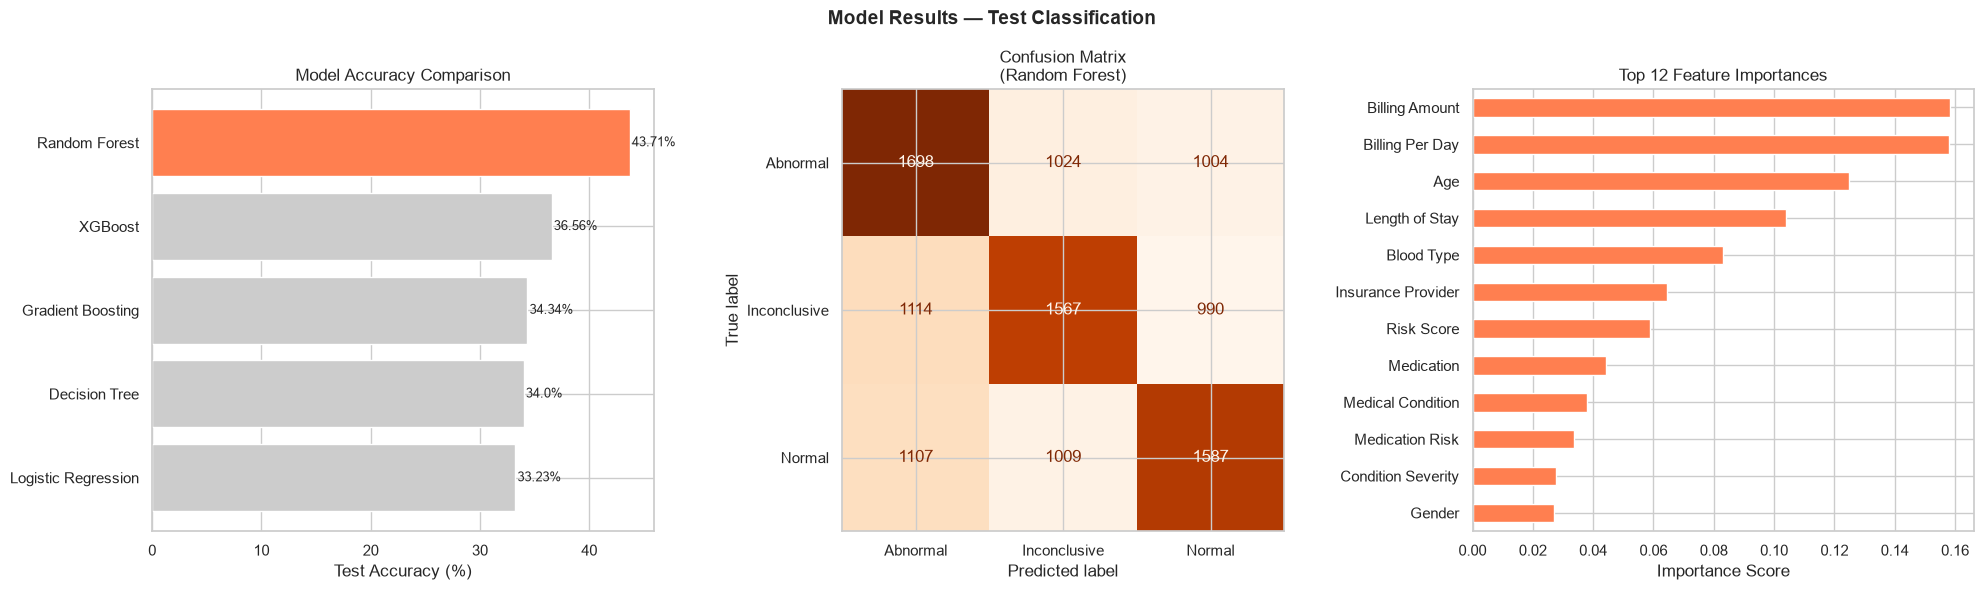

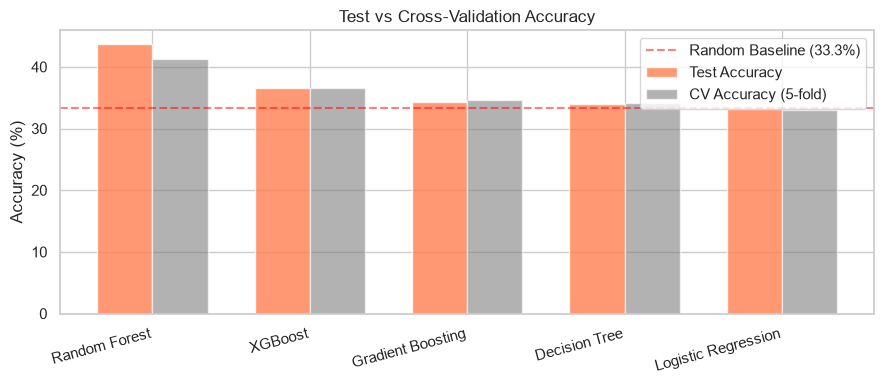

In [55]:
#  MODEL 2 — TEST RESULT CLASSIFICATION

test_features = [
    "Age", "Gender", "Blood Type", "Medical Condition",
    "Insurance Provider", "Billing Amount", "Admission Type",
    "Medication", "Length of Stay", "Condition Severity",
    "Urgency Score", "Age Group", "Risk Score",
    "Billing Per Day", "Medication Risk", "High Billing", "Long Stay"
]

le_test    = le_dict["Test Results"]
X_test_df  = df_model[test_features]
y_test_tar = df_model["Test Results"]   # already encoded above

scaler_test = StandardScaler()
X_test_scaled = scaler_test.fit_transform(X_test_df)

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(
    X_test_scaled, y_test_tar,
    test_size=0.2, random_state=42, stratify=y_test_tar)

print(f"\nTest Result Classification — Train: {X_tr_t.shape}, Test: {X_te_t.shape}")
print(f"Class distribution in train:\n{pd.Series(y_tr_t).value_counts()}")

test_results, test_best_name, test_best_model, test_best_preds, test_trained = \
    compare_models(X_tr_t, X_te_t, y_tr_t, y_te_t,
                   label_names=le_test.classes_,
                   title="MODEL 2 — TEST RESULT CLASSIFICATION COMPARISON")

plot_model_results(
    results_df     = test_results,
    y_test         = y_te_t,
    best_preds     = test_best_preds,
    best_name      = test_best_name,
    label_names    = le_test.classes_,
    feature_names  = test_features,
    best_model     = test_best_model,
    trained_models = test_trained,
    color          = "coral",
    filename_prefix= "test_classification"
)

In [56]:
#  FINAL SUMMARY TABLE

print("\n" + "═"*60)
print("           FINAL MODEL PERFORMANCE SUMMARY")
print("═"*60)
print(f"\n{'Model':<35} {'Best Algo':<22} {'Accuracy':>10}")
print("-"*60)

s_acc = stay_results.iloc[0]["Test Accuracy"]
t_acc = test_results.iloc[0]["Test Accuracy"]

print(f"{'Stay Classification':<35} {stay_best_name:<22} {s_acc:>9}%")
print(f"{'Test Result Classification':<35} {test_best_name:<22} {t_acc:>9}%")
print(f"\n{'Random Baseline (3 classes)':<35} {'—':<22} {'33.33%':>10}")
print("\n⚠  Note: Low accuracy is EXPECTED on this synthetic dataset.")
print("   All features were randomly generated with zero inter-column")
print("   correlation. The ML pipeline itself is correctly implemented.")
print("═"*60)


════════════════════════════════════════════════════════════
           FINAL MODEL PERFORMANCE SUMMARY
════════════════════════════════════════════════════════════

Model                               Best Algo                Accuracy
------------------------------------------------------------
Stay Classification                 Gradient Boosting          46.82%
Test Result Classification          Random Forest              43.71%

Random Baseline (3 classes)         —                          33.33%

⚠  Note: Low accuracy is EXPECTED on this synthetic dataset.
   All features were randomly generated with zero inter-column
   correlation. The ML pipeline itself is correctly implemented.
════════════════════════════════════════════════════════════
